In [2]:
import torch
import math
import numpy as np

from torch.nn import BCEWithLogitsLoss, BCELoss, CrossEntropyLoss
from torch import nn

outputs_dict = {"Xerostomia": torch.tensor([[0.1], [1.5], [0.3], [1.4], [0.9]]), "Dysphagia": torch.tensor([[0.4], [0.3], [0.2], [0.1], [0.8]])}
label_dict = {"Xerostomia": torch.tensor([0, 1, 0, 1, 1]), "Dysphagia": torch.tensor([1, -1, 0, 1, 0])}
labels_dict = label_dict.copy()
endpoint_list = ["Xerostomia", "Dysphagia"]

loss_function = BCEWithLogitsLoss(reduction='none', pos_weight=torch.tensor([1, -2]))

valid_endpoints_as_tensor = torch.tensor([0, 1])

In [31]:



class SB_ECE_Loss(nn.Module):
    """
    Soft-Binning Expected Calibration Error (SB-ECE) 
    """
    def __init__(self,
                 n_bins: int = 10,
                 T: float = 0.01,
                 device: torch.device = torch.device('cpu'),
                 reduction: str = 'none') -> None:
        super(SB_ECE_Loss, self).__init__()

        self.n_bins = n_bins
        self.T = T
        self.device = device
        self.reduction = reduction
        
        # find the centers of each bin
        bin_boundaries = torch.linspace(0, 1, n_bins + 1)[:-1]  #  (remove the last element as torch.linspace `does` include the end point (np.linspace does not))
        bin_width = ((bin_boundaries[1] - bin_boundaries[0])/2) 
        self.bin_centers = bin_boundaries + bin_width       

        self.columnwise_softmax = torch.nn.Softmax(dim=0)
    

    def forward(self, logits: torch.Tensor, targets: torch.LongTensor ) -> torch.Tensor:
        #confidences_all = torch.sigmoid(logits)
        confidences_all = logits
        targets_all = targets
        #N = len(confidences)  # get the number of predictions in this batch
        orig_shape = confidences_all.shape
        #print(orig_shape)
        N = torch.numel(confidences_all)
        m = self.n_bins

        template = torch.zeros_like(confidences_all)
        
        for idx, (confidences, targets) in enumerate(zip(confidences_all, targets_all)):
            N = torch.numel(confidences)
            print("CONF,", confidences)
                
            bin_centers_matrix = self.bin_centers.view(m,1).expand(m,N).to(self.device)  # bin centers as a matrix (each row contains a bin center, but the dimension is the same as the predictions matrix)
        
            pred_confidences_matrix = confidences.view(1,N).expand(m,N)  # predictions as a tensor of size m x N (each prediction is a column, and there is one row per bin)
            # compute the soft ECE bin probabilities
            
            g = -(pred_confidences_matrix-bin_centers_matrix)**2/ self.T  # soft bin function
            g_matrix = self.columnwise_softmax(g)        

            true_labels_matrix = targets.float().view(1,N).expand(m,N)
            Accuracy_matrix = true_labels_matrix * g_matrix
            bin_accuracies = torch.sum(Accuracy_matrix, dim = 1)  # accuracy of each bin

            S = torch.sum(g_matrix, dim = 1) # size of each bin
            S_check = torch.eq(S, torch.zeros(m).to(self.device)).float()  
            A_hat = torch.div(bin_accuracies, S+S_check).view(m,1)  # mean accuracy of all bins
            A_hat_matrix = A_hat.expand(m,N)
            temp_matrix = ((A_hat_matrix - pred_confidences_matrix)**2)*g_matrix

            print(temp_matrix.shape)
            temp2 = torch.sum(temp_matrix, dim = 0)
            print(temp2.shape)
            template[idx] = temp2
            print("TEMPLATE", template)
            print(template.sum(axis=1))

        return (1/N*torch.sum(temp_matrix))**(1/2)
        #loss = torch.reshape(temp_matrix, orig_shape)
        #return loss




preds = torch.tensor([[0.1, 0.9, 0.4, 0.25], [0.4, 0.3, 0.2, 0.1]]).T
labels = torch.tensor([[0, 1, 0, 1], [1, 0, 0, 1]]).T

#preds = torch.tensor([[0.1, 0.9, 0.4, 0.25]])
#labels = torch.tensor([[0, 1, 0, 1]])

SECE_loss = SB_ECE_Loss(n_bins=10, T=0.01, device=torch.device('cpu'), reduction='none')

SECE_loss(logits=preds, targets=labels)

torch.Size([4, 2])
CONF, tensor([0.1000, 0.4000])
torch.Size([10, 2])
torch.Size([2])
TEMPLATE tensor([[0.0194, 0.3374],
        [0.0000, 0.0000],
        [0.0000, 0.0000],
        [0.0000, 0.0000]])
tensor([0.3568, 0.0000, 0.0000, 0.0000])
CONF, tensor([0.9000, 0.3000])
torch.Size([10, 2])
torch.Size([2])
TEMPLATE tensor([[0.0194, 0.3374],
        [0.0100, 0.0900],
        [0.0000, 0.0000],
        [0.0000, 0.0000]])
tensor([0.3568, 0.1000, 0.0000, 0.0000])
CONF, tensor([0.4000, 0.2000])
torch.Size([10, 2])
torch.Size([2])
TEMPLATE tensor([[0.0194, 0.3374],
        [0.0100, 0.0900],
        [0.1600, 0.0400],
        [0.0000, 0.0000]])
tensor([0.3568, 0.1000, 0.2000, 0.0000])
CONF, tensor([0.2500, 0.1000])
torch.Size([10, 2])
torch.Size([2])
TEMPLATE tensor([[0.0194, 0.3374],
        [0.0100, 0.0900],
        [0.1600, 0.0400],
        [0.5625, 0.8100]])
tensor([0.3568, 0.1000, 0.2000, 1.3725])


tensor(0.8284)

In [22]:
# 3 toxicities, batch size 4 -> torch size [4,3]
preds = torch.tensor([[0.1, 0.9, 0.4, 0.25], [0.4, 0.3, 0.2, 0.1], [0.4, 0.3, 0.2, 0.1]]).T
labels = torch.tensor([[0, 1, 0, 1], [1, 0, 0, 1], [1,0,0,0]]).T

for idx, preds_per_tox in enumerate(preds):
    print(idx, preds_per_tox)

0 tensor([0.1000, 0.4000, 0.4000])
1 tensor([0.9000, 0.3000, 0.3000])
2 tensor([0.4000, 0.2000, 0.2000])
3 tensor([0.2500, 0.1000, 0.1000])


In [21]:
preds.shape

torch.Size([4, 3])

In [10]:
SECE_loss = SB_ECE_Loss(n_bins=10, T=0.01, device=torch.device('cpu'), reduction='none')

outputs_dict = {"Xerostomia": torch.tensor([[0.1], [0.9], [0.4], [0.25]]), "Dysphagia": torch.tensor([[0.4], [0.3], [0.2], [0.1]])}
label_dict = {"Xerostomia": torch.tensor([0, 1, 0, 1]), "Dysphagia": torch.tensor([1, -1, 0, 1])}


SECE_loss(outputs_dict["Xerostomia"], label_dict["Xerostomia"])

tensor(0.1845)

In [1]:
def SBECE(num_bins, confidences, true_labels, T, device):
    N = len(confidences)  # get the number of predictions in this batch
    m = num_bins

    bin_boundaries = torch.linspace(0, 1, num_bins + 1)[:-1]  # set the bin thresholds (remove the last element as torch.linspace does include the end point (np.linspace does not))
    bin_width = ((bin_boundaries[1] - bin_boundaries[0])/2)   # bin widths
    bin_centers = bin_boundaries + bin_width       # find the center of each bin

    pred_confidences_matrix = confidences.view(1,N).expand(m,N)  # predictions as a tensor of size m x N (each prediction is a column, and there is one row per bin)
    
    bin_centers_matrix = bin_centers.view(m,1) .expand(m,N).to(device)  # bin centers as a matrix (each row contains a bin center, but the dimension is the same as the predictions matrix)
    
    # compute the soft ECE bin probabilities
    columnwise_softmax = torch.nn.Softmax(dim=0)
    g = -(pred_confidences_matrix-bin_centers_matrix)**2/T  # soft bin function
    g_matrix = columnwise_softmax(g)        

    true_labels_matrix = true_labels.float().view(1,N).expand(m,N)
    Accuracy_matrix = true_labels_matrix * g_matrix
    bin_accuracies = torch.sum(Accuracy_matrix, dim = 1)  # accuracy of each bin

    S = torch.sum(g_matrix, dim = 1) # size of each bin
    S_check = torch.eq(S, torch.zeros(m).to(device)).float()  
    A_hat = torch.div(bin_accuracies, S+S_check).view(m,1)  # mean accuracy of all bins
    A_hat_matrix = A_hat.expand(m,N)
    temp_matrix = ((A_hat_matrix - pred_confidences_matrix)**2)*g_matrix

    return (1/N*torch.sum(temp_matrix))**(1/2)

In [74]:
outputs_dict = {"Xerostomia": torch.tensor([[0.1], [0.9], [0.4], [0.25]]), "Dysphagia": torch.tensor([[0.4], [0.3], [0.2], [0.1]])}
label_dict = {"Xerostomia": torch.tensor([0, 1, 0, 1]), "Dysphagia": torch.tensor([1, 0, 0, 1])}



SBECE(num_bins=10, confidences=outputs_dict["Xerostomia"], true_labels=label_dict["Xerostomia"], T=0.01, device=torch.device('cpu'))

tensor(0.2908)

In [ ]:
class ESD_Loss(nn.Module):
    def __init__(self,
                 device: torch.device,
                 reduction: str = 'none') -> None:
        super(ESD_Loss, self).__init__()

        self.device = device

    def forward(self, logits: torch.Tensor, targets: torch.LongTensor ) -> torch.Tensor:

        confidence1 = torch.sigmoid(logits)
        N1 = len(confidence1)  # number of predictions in this batch
        #confidence1 = torch.sigmoid(confidence1)
        confidence1= confidence1.view(N1)
        correct = targets.view(N1)

        val = correct.float() - confidence1   
        val = val.view(1,N1) 
        mask = torch.ones(N1,N1) - torch.eye(N1)
        mask = mask.to(self.device)
        confidence1_matrix = confidence1.expand(N1,N1)
        temp = (confidence1.view(1,N1).T).expand(N1,N1)
        tri = torch.le(confidence1_matrix,temp).float() 
        val_matrix = val.expand(N1,N1)
        x_matrix = torch.mul(val_matrix,tri)*mask
        g_bar = torch.sum(x_matrix, dim = 1)/(N1-1)
        x_matrix_squared = torch.mul(x_matrix, x_matrix)
        S_g = 1/(N1-2) * torch.sum(x_matrix_squared,dim=1) - (N1-1)/(N1-2) * torch.mul(g_bar,g_bar)

        # this is the ESD loss inside the square brackets of equation 10
        ESD_sum = torch.mul(g_bar, g_bar) - S_g/(N1-1)
        reg_loss = torch.sum(ESD_sum)/N1
        
        return reg_loss

In [8]:
def ESD(device, confidence1, correct):
    N1 = len(confidence1)  # number of predictions in this batch
    N1 = 8
    N1 = torch.numel(confidence1)
    #confidence1 = torch.sigmoid(confidence1)
    original_shape = confidence1.shape
    print(confidence1)
    confidence1= confidence1.view(N1)
    print(confidence1)
    correct = correct.view(N1)

    val = correct.float() - confidence1   
    val = val.view(1,N1) 
    mask = torch.ones(N1,N1) - torch.eye(N1)
    mask = mask.to(device)
    confidence1_matrix = confidence1.expand(N1,N1)
    temp = (confidence1.view(1,N1).T).expand(N1,N1)
    tri = torch.le(confidence1_matrix,temp).float() 
    val_matrix = val.expand(N1,N1)
    x_matrix = torch.mul(val_matrix,tri)*mask
    g_bar = torch.sum(x_matrix, dim = 1)/(N1-1)
    x_matrix_squared = torch.mul(x_matrix, x_matrix)
    S_g = 1/(N1-2) * torch.sum(x_matrix_squared,dim=1) - (N1-1)/(N1-2) * torch.mul(g_bar,g_bar)

    # this is the ESD loss inside the square brackets of equation 10
    ESD_sum = torch.mul(g_bar, g_bar) - S_g/(N1-1)
    #reg_loss = torch.sum(ESD_sum)/N1
    #print(ESD_sum)
    ESD_sum = torch.reshape(ESD_sum, original_shape)
    print(ESD_sum.shape, original_shape)
    
    return ESD_sum


preds = torch.tensor([[0.1, 0.9, 0.4, 0.25], [0.4, 0.3, 0.2, 0.1]])
labels = torch.tensor([[0, 1, 0, 1], [1, 0, 0, 1]])

ESD(confidence1=preds, correct=labels, device=torch.device('cpu'))

tensor([[0.1000, 0.9000, 0.4000, 0.2500],
        [0.4000, 0.3000, 0.2000, 0.1000]])
tensor([0.1000, 0.9000, 0.4000, 0.2500, 0.4000, 0.3000, 0.2000, 0.1000])
torch.Size([2, 4]) torch.Size([2, 4])


tensor([[-1.8626e-09, -1.1190e-02,  2.0238e-02, -1.1905e-02],
        [-2.9762e-02,  9.5238e-03, -4.2857e-03, -1.4552e-11]])

In [17]:
import config as cfg

loss_function = BCEWithLogitsLoss(reduction='none', pos_weight=torch.tensor([1, 2]))


inputs = torch.stack(list(outputs_dict.values()), dim=1).type(torch.float32) # transposed! so that num columns = num toxicities
targets = torch.stack(list(labels_dict.values()), dim=1).type(torch.float32)

inputs = torch.reshape(inputs, targets.shape).to(inputs.dtype)

# compute loss
batch_loss = loss_function(inputs, targets)
# mask out the losses of the missing labels
mask = torch.isin(targets, valid_endpoints_as_tensor)
#inv_mask = ~mask
batch_loss = torch.nan_to_num(batch_loss, nan=0.0)
batch_loss *= mask
# find the mean loss of the non-missing labels
batch_loss_mean = batch_loss.sum() / mask.sum()


# find the loss per endpoint (the column-wise mean of the batch_loss tensor)
per_toxicity_loss_dict = dict()
axis = 0
per_toxicity_loss = batch_loss.sum(axis=axis) / mask.sum(axis=axis)

for idx, endpoint in enumerate(endpoint_list):
    value = per_toxicity_loss[idx].item()
    per_toxicity_loss_dict[endpoint] = value if (not math.isnan(value)) else 0

# also get the non-weighted loss
# if we are not weighting the loss, then the unweighted_batch_loss_mean = batch_loss_mean, and unweighted_per_toxicity_loss_dict = per_toxicity_loss_dict
pos_weights = loss_function.pos_weight
unweighted_per_toxicity_loss_dict = dict()
if pos_weights is not None:
    unweighting_factor = torch.where(targets != 1, torch.ones_like(targets), pos_weights.expand(batch_loss.shape))
    unweighted_batch_loss = batch_loss / unweighting_factor
    print(batch_loss)
    print(unweighted_batch_loss)
    unweighted_batch_loss_mean = unweighted_batch_loss.sum() / mask.sum()

    unweighted_per_toxicity_loss = unweighted_batch_loss.sum(axis=axis) / mask.sum(axis=axis)
    for idx, endpoint in enumerate(endpoint_list):
        value = unweighted_per_toxicity_loss[idx].item()
        print(value)
        unweighted_per_toxicity_loss_dict[endpoint] = value if (not math.isnan(value)) else 0
    
else:
    unweighted_batch_loss_mean = batch_loss_mean
    for idx, endpoint in enumerate(endpoint_list):
        unweighted_per_toxicity_loss_dict[endpoint] = per_toxicity_loss_dict[endpoint]

tensor([[0.7444, 1.0260],
        [0.2014, 0.0000],
        [0.8544, 0.7981],
        [0.2204, 1.2888],
        [0.3412, 1.1711]])
tensor([[0.7444, 0.5130],
        [0.2014, 0.0000],
        [0.8544, 0.7981],
        [0.2204, 0.6444],
        [0.3412, 1.1711]])
0.47234734892845154
0.7816628217697144


In [18]:
batch_loss_mean, per_toxicity_loss_dict, unweighted_batch_loss_mean, unweighted_per_toxicity_loss_dict

(tensor(0.7384),
 {'Xerostomia': 0.47234734892845154, 'Dysphagia': 1.0710158348083496},
 tensor(0.6098),
 {'Xerostomia': 0.47234734892845154, 'Dysphagia': 0.7816628217697144})

In [42]:
pos_weight = torch.tensor([1, 2])

pos_weight2 = pos_weight.expand(batch_loss.shape)

In [41]:
pos_weight

tensor([1, 2])

In [40]:
batch_loss

tensor([[0.7444, 1.0260],
        [0.2014, 0.0000],
        [0.8544, 0.7981],
        [0.2204, 1.2888],
        [0.3412, 1.1711]])

In [43]:
batch_loss / pos_weight2

tensor([[0.7444, 0.5130],
        [0.2014, 0.0000],
        [0.8544, 0.3991],
        [0.2204, 0.6444],
        [0.3412, 0.5856]])

In [45]:
loss_function2 = BCEWithLogitsLoss(reduction='none')
print(loss_function2.pos_weight)

None


In [46]:
loss_function = BCEWithLogitsLoss(reduction='none', pos_weight=torch.tensor([1, 2]))



inputs = torch.stack(list(outputs_dict.values()), dim=1).type(torch.float32) # transposed! so that num columns = num toxicities
targets = torch.stack(list(labels_dict.values()), dim=1).type(torch.float32)

inputs = torch.reshape(inputs, targets.shape).to(inputs.dtype)

# compute loss
batch_loss = loss_function(inputs, targets)
print(batch_loss)
print(loss_function.pos_weight)
print(batch_loss/loss_function.pos_weight)



# mask out the losses of the missing labels
mask = torch.isin(targets, valid_endpoints_as_tensor)
#inv_mask = ~mask
batch_loss = torch.nan_to_num(batch_loss, nan=0.0)
batch_loss *= mask
# find the mean loss of the non-missing labels
batch_loss_mean = batch_loss.sum() / mask.sum()



# find the loss per endpoint (the column-wise mean of the batch_loss tensor)
per_toxicity_loss_dict = dict()
axis = 0
per_toxicity_loss = batch_loss.sum(axis=axis) / mask.sum(axis=axis)

for idx, endpoint in enumerate(endpoint_list):
    value = per_toxicity_loss[idx].item()
    per_toxicity_loss_dict[endpoint] = value if (not math.isnan(value)) else 0


# also get the non-weighted loss
# if we are not weighting the loss, then the unweighted_batch_loss_mean = batch_loss_mean, and unweighted_per_toxicity_loss_dict = per_toxicity_loss_dict
pos_weights = loss_function.pos_weight
unweighted_per_toxicity_loss_dict = dict()
if pos_weights is not None:
    unweighted_batch_loss = batch_loss * pos_weights.expand(batch_loss.shape)
    unweighted_batch_loss_mean = unweighted_batch_loss.sum(axis=axis) / mask.sum(axis=axis)
    
    for idx, endpoint in enumerate(endpoint_list):
        value = per_toxicity_loss[idx].item()
        unweighted_per_toxicity_loss_dict[endpoint] = value if (not math.isnan(value)) else 0
    
else:
    unweighted_batch_loss_mean = batch_loss_mean
    for idx, endpoint in enumerate(endpoint_list):
        unweighted_per_toxicity_loss_dict[endpoint] = per_toxicity_loss_dict[endpoint]


#batch_loss_mean, per_toxicity_loss_dict, unweighted_batch_loss_mean, unweighted_per_toxicity_loss_dict

print(per_toxicity_loss_dict)

print(unweighted_per_toxicity_loss_dict)

tensor([[0.7444, 1.0260],
        [0.2014, 0.6000],
        [0.8544, 0.7981],
        [0.2204, 1.2888],
        [0.3412, 1.1711]])
tensor([1, 2])
tensor([[0.7444, 0.5130],
        [0.2014, 0.3000],
        [0.8544, 0.3991],
        [0.2204, 0.6444],
        [0.3412, 0.5856]])
{'Xerostomia': 0.47234734892845154, 'Dysphagia': 1.0710158348083496}
{'Xerostomia': 0.47234734892845154, 'Dysphagia': 1.0710158348083496}


In [19]:
outputs_dict['Xerostomia'].size(), label_dict["Xerostomia"].size()

(torch.Size([5, 1]), torch.Size([5]))

In [20]:
import torch
import torch.nn as nn




# Example dictionary of tensors (predictions for each class)
predictions = {
    'class_1': torch.tensor([0.1, 0.2, 0.7, 0.1]),
    'class_2': torch.tensor([0.4, 0.3, 0.3, 0.2]),
}

# Convert dictionary of tensors to a single tensor by stacking
# along a new dimension. Ensure all tensors have the same shape.
stacked_predictions = torch.stack(list(predictions.values()), dim=1)
print(stacked_predictions)
# Example target tensor (ground truth labels) for multi-label classification
# Here, each row represents a sample and each column represents a class.
# A value of 1 indicates the class is present for the sample, and 0 otherwise.
target = torch.tensor([
    [1, 0],
    [0, 1],
    [1, 1],
    [1, 0]
], dtype=torch.float32)

# Example weights for each class
# For multi-label classification, you might want to adjust these weights based on
# the imbalance in each label rather than across classes.
weights = torch.tensor([0.5, 1.0, 1.5]) # Adjust these weights as needed

# Define the loss function with pos_weight for handling class imbalance
criterion = nn.BCEWithLogitsLoss(pos_weight=weights)

# Compute the loss
loss = criterion(stacked_predictions, target)

print(f"Loss: {loss.item()}")

tensor([[0.1000, 0.4000],
        [0.2000, 0.3000],
        [0.7000, 0.3000],
        [0.1000, 0.2000]])


RuntimeError: The size of tensor a (3) must match the size of tensor b (2) at non-singleton dimension 1

In [21]:
sigmoid_act = torch.nn.Sigmoid()

sigmoid_act(torch.tensor(0.81666416))

tensor(0.6935)

In [29]:
weights = torch.tensor([1, 1.0])
loss_function = BCEWithLogitsLoss(reduction='none', pos_weight=torch.tensor([1, -2]))
#loss_function = BCELoss(reduction='none')

outputs_dict = {"Xerostomia": torch.tensor([[0.1], [1.5], [0.3], [1.4], [0.9]]), "Dysphagia": torch.tensor([[0.4], [0.3], [0.2], [0.1], [0.8]])}
label_dict = {"Xerostomia": torch.tensor([0, 1, 0, 1, 1]), "Dysphagia": torch.tensor([1, -1, 0, 1, 0])}

#outputs_dict = {"Xerostomia": torch.tensor([[0.1]]), "Dysphagia": torch.tensor([[0.4]])}
#label_dict = {"Xerostomia": torch.tensor([0]), "Dysphagia": torch.tensor([1])}

# calculate loss
# convert the dictioanry to a tensor
inputs = torch.stack([t for t in outputs_dict.values()], dim=1)  # transposed! so that num columns = num toxicities
targets = torch.stack([t for t in label_dict.values()], dim=1).type(torch.float32)

print(targets)
inputs = torch.reshape(inputs, targets.shape).to(inputs.dtype)

batch_loss = loss_function(inputs, targets)
print(batch_loss)

# mask out the missing endpoints
mask = torch.isin(targets, valid_endpoints_as_tensor)
batch_loss = batch_loss * mask


print(batch_loss)
# sum and average the loss of this batch
batch_loss = batch_loss.sum() / mask.sum()
print(batch_loss)

tensor([[ 0.,  1.],
        [ 1., -1.],
        [ 0.,  0.],
        [ 1.,  1.],
        [ 1.,  0.]])
tensor([[ 0.7444, -1.0260],
        [ 0.2014,  2.8174],
        [ 0.8544,  0.7981],
        [ 0.2204, -1.2888],
        [ 0.3412,  1.1711]])
tensor([[ 0.7444, -1.0260],
        [ 0.2014,  0.0000],
        [ 0.8544,  0.7981],
        [ 0.2204, -1.2888],
        [ 0.3412,  1.1711]])
tensor(0.2240)


In [16]:
loss_function = BCEWithLogitsLoss(reduction='none')
#loss_function = BCELoss(reduction='none')

y_pred_dict = dict()
y_true_dict = dict()
valid_y_pred_dict = dict()
valid_y_true_dict = dict()
for endpoint in endpoint_list:
    y_pred_dict[endpoint] = torch.as_tensor([], dtype=torch.float32)
    y_true_dict[endpoint] = torch.as_tensor([], dtype=torch.int8)
    valid_y_pred_dict[endpoint] = torch.as_tensor([], dtype=torch.float32)
    valid_y_true_dict[endpoint] = torch.as_tensor([], dtype=torch.int8)

loss = 0

nr_of_endpoints_with_loss = 0
# save ALL predictions on this epoch (including ones for missing labels)
for endpoint in endpoint_list:
    y_pred_dict[endpoint] = torch.cat([y_pred_dict[endpoint], outputs_dict[endpoint]], dim=0)
    y_true_dict[endpoint] = torch.cat([y_true_dict[endpoint], label_dict[endpoint]], dim=0)


# calculate loss
# convert the dictioanry to a tensor
inputs = torch.stack(list(outputs_dict.values()), dim=0).type(torch.float32).T  # transposed! so that num columns = num toxicities
targets = torch.stack(list(label_dict.values()), dim=0).type(torch.float32).T
# compute loss
batch_loss = loss_function(inputs, targets)

# APPLY WEIGHTS
batch_loss = batch_loss * torch.tensor([1,4])
# mask out the missing endpoints
mask = torch.isin(targets, valid_endpoints_as_tensor)
batch_loss = batch_loss * mask


print(batch_loss)
# sum and average the loss of this batch
batch_loss = batch_loss.sum() / mask.sum()


C:\Users\Daniel (7781D3A3)\AppData\Local\Temp\2\ipykernel_12692\2544165544.py:25: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at ..\aten\src\ATen\native\TensorShape.cpp:3641.)
  inputs = torch.stack(list(outputs_dict.values()), dim=0).type(torch.float32).T  # transposed! so that num columns = num toxicities


ValueError: Target size (torch.Size([5, 2])) must be the same as input size (torch.Size([1, 5, 2]))

In [17]:
loss_function = BCEWithLogitsLoss(reduction='none', pos_weight=torch.tensor([2,3]))
#loss_function = BCELoss(reduction='none')

y_pred_dict = dict()
y_true_dict = dict()
valid_y_pred_dict = dict()
valid_y_true_dict = dict()
for endpoint in endpoint_list:
    y_pred_dict[endpoint] = torch.as_tensor([], dtype=torch.float32)
    y_true_dict[endpoint] = torch.as_tensor([], dtype=torch.int8)
    valid_y_pred_dict[endpoint] = torch.as_tensor([], dtype=torch.float32)
    valid_y_true_dict[endpoint] = torch.as_tensor([], dtype=torch.int8)

loss = 0

nr_of_endpoints_with_loss = 0
# save ALL predictions on this epoch (including ones for missing labels)
for endpoint in endpoint_list:
    y_pred_dict[endpoint] = torch.cat([y_pred_dict[endpoint], outputs_dict[endpoint]], dim=0)
    y_true_dict[endpoint] = torch.cat([y_true_dict[endpoint], label_dict[endpoint]], dim=0)


# calculate loss
# convert the dictioanry to a tensor
inputs = torch.stack(list(outputs_dict.values()), dim=0).type(torch.float32).T  # transposed! so that num columns = num toxicities
targets = torch.stack(list(label_dict.values()), dim=0).type(torch.float32).T
# compute loss
batch_loss = loss_function(inputs, targets)

# APPLY WEIGHTS
batch_loss = batch_loss * torch.tensor([1,4])
# mask out the missing endpoints
mask = torch.isin(targets, valid_endpoints_as_tensor)
batch_loss = batch_loss * mask

print(batch_loss)
# sum and average the loss of this batch
batch_loss_mean = batch_loss.sum() / mask.sum()

axis = 0
print(batch_loss.sum(axis=axis) / mask.sum(axis=axis))

per_toxicity_loss = batch_loss.sum(axis=axis) / mask.sum(axis=axis)

ValueError: Target size (torch.Size([5, 2])) must be the same as input size (torch.Size([1, 5, 2]))

In [6]:
per_toxicity_loss_dict = dict()


for idx, endpoint in enumerate(endpoint_list):
    per_toxicity_loss_dict[endpoint] = per_toxicity_loss[idx]

for tox in endpoint_list:
    print(f"{tox} loss: {per_toxicity_loss_dict[tox]:.3f}")

Xerostomia loss: 0.901
Dysphagia loss: 5.441


In [10]:
#per_toxicity_loss_dict += per_toxicity_loss_dict

def append_to_list_dict(main_dict, append_dict):
    """
    Return the sum of two dictionaries that have identical keys.
    `main_dict` must be a dictionary with lists as values!
    Args:
        main_dict: A dictionary with lists as values
        append_dict: A dictionary with one value per key, to be appended to main_dict's lists
    Returns:
        main_dict with a value appended to each key's list
    """
    
    for key in main_dict:
        main_dict[key].append(append_dict[key])

    return main_dict

dict1 = {'a': [1], 'b': [2], 'c': [3]}
dict2 = {'a': 4, 'b': 5, 'c': 6}


append_to_list_dict(dict1, dict2)


{'a': [1, 4], 'b': [2, 5], 'c': [3, 6]}

In [79]:
loss_function = BCEWithLogitsLoss(reduction='none')
#loss_function = BCELoss(reduction='none')

y_pred_dict = dict()
y_true_dict = dict()
valid_y_pred_dict = dict()
valid_y_true_dict = dict()
for endpoint in endpoint_list:
    y_pred_dict[endpoint] = torch.as_tensor([], dtype=torch.float32)
    y_true_dict[endpoint] = torch.as_tensor([], dtype=torch.int8)
    valid_y_pred_dict[endpoint] = torch.as_tensor([], dtype=torch.float32)
    valid_y_true_dict[endpoint] = torch.as_tensor([], dtype=torch.int8)

loss = 0

nr_of_endpoints_with_loss = 0
# save ALL predictions on this epoch (including ones for missing labels)
for endpoint in endpoint_list:
    y_pred_dict[endpoint] = torch.cat([y_pred_dict[endpoint], outputs_dict[endpoint]], dim=0)
    y_true_dict[endpoint] = torch.cat([y_true_dict[endpoint], label_dict[endpoint]], dim=0)


# calculate loss
# convert the dictioanry to a tensor
inputs = torch.stack(list(outputs_dict.values()), dim=0).type(torch.float32).T  # transposed! so that num columns = num toxicities
targets = torch.stack(list(label_dict.values()), dim=0).type(torch.float32).T
# compute loss
batch_loss = loss_function(inputs, targets)

# APPLY WEIGHTS
batch_loss = batch_loss * torch.tensor([1,4])

# mask out the missing endpoints
mask = torch.isin(targets, valid_endpoints_as_tensor)
#batch_loss = batch_loss * mask

# APPLY NORMALISATION TO THESE WEIGHTS
label_pos_weights = torch.tensor([2,3], dtype=torch.float32)
label_neg_weights = torch.ones_like(label_pos_weights, dtype=torch.float32)

pos_neg_sum = sum(label_pos_weights + label_neg_weights)

label_pos_weights /= pos_neg_sum
label_neg_weights /= pos_neg_sum

pos_mask = torch.isin(targets, torch.tensor([1])) # only the positive examples
pos_weight_multiplier = pos_mask * label_pos_weights + ~pos_mask * label_neg_weights         # per-class pos_weight (2 for first, 3 for second)

print(pos_weight_multiplier)

#pos_weight_multiplier[pos_weight_multiplier==0] = 1

#pos_weight_multiplier[~pos_mask] = 2
#pos_weight_multiplier = mask * torch.tensor([2,3])
batch_loss = batch_loss * pos_weight_multiplier

batch_loss = batch_loss * mask

print(batch_loss)
# sum and average the loss of this batch
batch_loss = batch_loss.sum() / mask.sum()


NameError: name 'BCEWithLogitsLoss' is not defined

In [80]:
pos_neg_sum

tensor(7)

In [74]:
pos_weight_multiplier

tensor([[1, 9],
        [4, 9],
        [1, 1],
        [4, 9],
        [4, 1]])

In [72]:

pos_weights_tensor

tensor([[1, 3],
        [2, 3],
        [1, 1],
        [2, 3],
        [2, 1]])

In [69]:
pos_mask

tensor([[False,  True],
        [ True,  True],
        [False, False],
        [ True,  True],
        [ True, False]])

In [56]:
pos_mask * torch.tensor([2,3])

tensor([[0, 3],
        [2, 3],
        [0, 0],
        [2, 3],
        [2, 0]])

In [8]:
1e-1

0.1

In [7]:
from utils.losses import FocalLoss, AsymmetricLossOptimized

#loss_function = BCEWithLogitsLoss(reduction='none', weight=torch.tensor([1,4]), pos_weight=torch.tensor([2,3]))
#loss_function = BCELoss(reduction='none')
#loss_function = FocalLoss(reduction='none', alpha=torch.tensor([0.25,0.9]), gamma=2)
loss_function = AsymmetricLossOptimized(gamma_neg=torch.tensor([1,1]), gamma_pos=torch.tensor([1,1]), clip=0.05)
y_pred_dict = dict()
y_true_dict = dict()
valid_y_pred_dict = dict()
valid_y_true_dict = dict()
for endpoint in endpoint_list:
    y_pred_dict[endpoint] = torch.as_tensor([], dtype=torch.float32)
    y_true_dict[endpoint] = torch.as_tensor([], dtype=torch.int8)
    valid_y_pred_dict[endpoint] = torch.as_tensor([], dtype=torch.float32)
    valid_y_true_dict[endpoint] = torch.as_tensor([], dtype=torch.int8)

loss = 0
nr_of_endpoints_with_loss = 0
# save ALL predictions on this epoch (including ones for missing labels)
for endpoint in endpoint_list:
    y_pred_dict[endpoint] = torch.cat([y_pred_dict[endpoint], outputs_dict[endpoint]], dim=0)
    y_true_dict[endpoint] = torch.cat([y_true_dict[endpoint], label_dict[endpoint]], dim=0)


# calculate loss
# convert the dictioanry to a tensor
inputs = torch.stack(list(outputs_dict.values()), dim=0).type(torch.float32).T  # transposed! so that num columns = num toxicities
targets = torch.stack(list(label_dict.values()), dim=0).type(torch.float32).T
# compute loss
batch_loss = loss_function(inputs, targets)

# mask out the missing endpoints
mask = torch.isin(targets, valid_endpoints_as_tensor)
batch_loss = batch_loss * mask


print(batch_loss)
# sum and average the loss of this batch
batch_loss = batch_loss.sum() / mask.sum()


tensor([[0.3060, 0.2059],
        [0.2693, 0.0000],
        [0.3898, 0.3463],
        [0.2059, 0.3061],
        [0.0986, 0.6538]])


In [5]:
targets

tensor([[ 0.,  1.],
        [ 1., -1.],
        [ 0.,  0.],
        [ 1.,  1.],
        [ 1.,  0.]])

In [6]:
targets = torch.stack(list(label_dict.values()), dim=0).type(torch.float32).T
targets

tensor([[ 0.,  1.],
        [ 1., -1.],
        [ 0.,  0.],
        [ 1.,  1.],
        [ 1.,  0.]], device='cuda:0')

In [7]:
targets = torch.stack(list(label_dict.values()), dim=0).type(torch.float32).mT
targets

tensor([[ 0.,  1.],
        [ 1., -1.],
        [ 0.,  0.],
        [ 1.,  1.],
        [ 1.,  0.]], device='cuda:0')

In [246]:
loss_function = BCEWithLogitsLoss(reduction='none')
#loss_function = BCELoss(reduction='none')

y_pred_dict = dict()
y_true_dict = dict()
valid_y_pred_dict = dict()
valid_y_true_dict = dict()
for endpoint in endpoint_list:
    y_pred_dict[endpoint] = torch.as_tensor([], dtype=torch.float32)
    y_true_dict[endpoint] = torch.as_tensor([], dtype=torch.int8)
    valid_y_pred_dict[endpoint] = torch.as_tensor([], dtype=torch.float32)
    valid_y_true_dict[endpoint] = torch.as_tensor([], dtype=torch.int8)

loss = 0

nr_of_endpoints_with_loss = 0
for endpoint in endpoint_list:
    # save ALL predictions on this epoch (including ones for missing labels)
    y_pred_dict[endpoint] = torch.cat([y_pred_dict[endpoint], outputs_dict[endpoint]], dim=0)
    y_true_dict[endpoint] = torch.cat([y_true_dict[endpoint], label_dict[endpoint]], dim=0)



    # Only consider patients with non-missing value for `endpoint`, i.e., labels in `valid_endpoint_values`
    mask = torch.isin(label_dict[endpoint], valid_endpoints_as_tensor)
    outputs = outputs_dict[endpoint][mask]
    labels = label_dict[endpoint][mask]
    
    # those patients (for AUC calculation later)
    valid_y_pred_dict[endpoint] = torch.cat([valid_y_pred_dict[endpoint], outputs], dim=0)
    valid_y_true_dict[endpoint] = torch.cat([valid_y_true_dict[endpoint], labels], dim=0)
    batch_size_endpoint_after = outputs.shape[0]

    if batch_size_endpoint_after > 0:
        print(outputs, labels)
        batch_loss = loss_function(outputs, torch.reshape(labels, outputs.shape).to(outputs.dtype))
        loss += sum(batch_loss)
        nr_of_endpoints_with_loss += batch_size_endpoint_after

# Scale loss value: has impact on weight updates! Else, the weights will be updated
# `nr_of_endpoints_with_loss` times more aggresively than normal. Note: during validation, the weights
# will NOT be updated, but we use the same calculation as during train(), for consistency (of plots)

loss /= nr_of_endpoints_with_loss
# Evaluate model (internal validation set)
loss.item()

tensor([0.1000, 0.2000, 0.3000, 0.4000, 0.9000]) tensor([0, 1, 0, 1, 1])
tensor([0.4000, 0.2000, 0.1000, 0.8000]) tensor([1, 0, 1, 0])


0.6864123940467834

In [248]:
loss_function = BCEWithLogitsLoss(reduction='none')
#loss_function = BCELoss(reduction='none')

inputs = torch.tensor(torch.stack(list(outputs_dict.values()), dim=0), dtype=torch.float32).T
targets = torch.tensor(torch.stack(list(label_dict.values()), dim=0), dtype=torch.float32).T

#predictions = inputs.clone().T
#labels = targets.clone().T

mask = torch.isin(targets, valid_endpoints_as_tensor, invert=True)
mask2 = torch.isin(targets, valid_endpoints_as_tensor)
print(mask)
#inputs[mask] = 0.0
#targets[mask] = 0.0

# Example class weights for positive instances in each class
# You can adjust these weights based on your dataset's class imbalance
#class_weights = torch.tensor([1.0, 1.0, 1.0, 1.0, 1.0]) # Adjust these weights as needed

# Initialize the loss function with pos_weight
#loss_function = nn.BCEWithLogitsLoss(pos_weight=class_weights)
#print(inputs, targets)
# Calculate the loss
loss = loss_function(inputs, targets)


loss[mask] = 0
print(loss)
loss.sum() / mask2.sum()

tensor([[False, False],
        [False,  True],
        [False, False],
        [False, False],
        [False, False]])
tensor([[0.7444, 0.5130],
        [0.5981, 0.0000],
        [0.8544, 0.7981],
        [0.5130, 0.6444],
        [0.3412, 1.1711]])


C:\Users\danie\AppData\Local\Temp\ipykernel_41268\2746698485.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  inputs = torch.tensor(torch.stack(list(outputs_dict.values()), dim=0), dtype=torch.float32).T
C:\Users\danie\AppData\Local\Temp\ipykernel_41268\2746698485.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  targets = torch.tensor(torch.stack(list(label_dict.values()), dim=0), dtype=torch.float32).T


tensor(0.6864)

In [165]:
loss.sum()

tensor(4.6655)

In [72]:
predictions = torch.stack(list(outputs_dict.values()), dim=0)
labels = torch.stack(list(label_dict.values()), dim=0)

mask = ((labels == 0) | (labels == 1)).float()
    
# Apply the mask to predictions and labels
masked_predictions = predictions * mask
masked_labels = labels * mask


loss = loss_function(masked_predictions, masked_labels)
loss.item() / int(mask.sum())

0.09568936484200614

In [134]:
loss_function = BCEWithLogitsLoss(reduction='none')

loss = loss_function(torch.tensor([1], dtype=torch.float), torch.tensor([1], dtype=torch.float))
loss

tensor([0.3133])

7

# AUC Metrics

In [8]:
import torch

outputs_dict = {"Xerostomia": torch.tensor([0.1, 0.2, 0.3, 0.4]), "Dysphagia": torch.tensor([0.4, 0.3, 0.2, 0.1])}
label_dict = {"Xerostomia": torch.tensor([0, 1, 0, 1]), "Dysphagia": torch.tensor([1, -1, 0, 1])}

endpoint_list = ["Xerostomia", "Dysphagia"]

valid_endpoints_as_tensor = torch.tensor([0, 1])




In [14]:
endpoint_unfrozen_impoved_dict = {"A": 0, "B":10}

endpoints_supassed_patience = [key for key, value in endpoint_unfrozen_impoved_dict.items() if value >= 11]

len(endpoints_supassed_patience)

0

In [17]:
temp = [1]

for t in temp:
    print(0)

0


In [18]:
if temp:
    print(1)

1


In [ ]:
A = [element for element in A if element not in B]


In [9]:
# remove the missing labels
for endpoint in endpoint_list:
    mask = torch.isin(label_dict[endpoint], valid_endpoints_as_tensor) # mask = the labels to keep
    outputs_dict[endpoint] = outputs_dict[endpoint][mask]
    label_dict[endpoint] = label_dict[endpoint][mask]

outputs_dict

{'Xerostomia': tensor([0.1000, 0.2000, 0.3000, 0.4000]),
 'Dysphagia': tensor([0.4000, 0.2000, 0.1000])}

In [7]:
from torchmetrics.classification import MultilabelAUROC


preds = torch.tensor([[0.75, 0.05, 0.35],
                       [0.45, 0.75, 0.05],
                       [0.05, 0.55, 0.75],
                       [0.05, 0.65, 0.05]], device='cuda')
target = torch.tensor([[1, 0, 1],
                        [0, 0, 0],
                        [0, 1, 1],
                        [1, 1, 1]], device='cuda')

ml_auroc = MultilabelAUROC(num_labels=3, average=None, thresholds=None)
ml_auroc(preds, target)


tensor([0.6250, 0.5000, 0.8333], device='cuda:0')

In [18]:
from torcheval.metrics import BinaryAUROC
from sklearn.metrics import roc_auc_score

auc_metric = BinaryAUROC(num_tasks=3)
auc_metric.reset()
auc_metric.update(preds.T, target.T)

print(auc_metric.compute())

auc_metric = BinaryAUROC(num_tasks=1)
for i in range(preds.shape[1]):
    p = preds[:, i].cpu()
    t = target[:, i].cpu()
    auc_metric.reset()
    auc_metric.update(p, t)
    
    print(auc_metric.compute())
    print(roc_auc_score(target.cpu(), preds.cpu()))

tensor([0.6250, 0.5000, 0.8333], dtype=torch.float64)
tensor(0.6250, dtype=torch.float64)
0.6527777777777778
tensor(0.5000, dtype=torch.float64)
0.6527777777777778
tensor(0.8333, dtype=torch.float64)
0.6527777777777778


In [204]:
pip install torchmetrics

   ---------------------------------------- 0.0/840.4 kB ? eta -:--:--
   ---------- ----------------------------- 225.3/840.4 kB 4.6 MB/s eta 0:00:01
   ------------------------------- -------- 665.6/840.4 kB 7.0 MB/s eta 0:00:01
   ---------------------------------------- 840.4/840.4 kB 6.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [63]:
masked_labels

tensor([[0., 1., 0., 1.],
        [1., -0., 0., 1.]])

In [64]:
labels

tensor([[ 0,  1,  0,  1],
        [ 1, -1,  0,  1]])

In [23]:
tensor_3d = torch.stack(list(outputs_dict.values()))
tensor_3d

tensor([[0.1000, 0.2000, 0.3000, 0.4000],
        [0.4000, 0.3000, 0.2000, 0.1000]])

In [14]:
outputs_dict["Xerostomia"]

tensor([0.1000, 0.2000, 0.3000, 0.4000])

# Plots

![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

In [2]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import os

# Create random loss values
x = np.linspace(0, 10, 100)
y = np.exp(-x) + np.random.normal(0, 0.01, 100)

Xero_train = np.exp(-x) + np.random.normal(0, 0.01, 100)
Xero_val = np.exp(-x) + np.random.normal(0, 0.01, 100)

Taste_train = np.exp(-1 * x) + np.random.normal(0, 0.05, 100)
Taste_val = np.exp(-1 * x) + np.random.normal(0, 0.05, 100)

Sticky_train = np.exp(-1 * x) + np.random.normal(0, 0.05, 100)
Sticky_val = np.exp(-1 * x) + np.random.normal(0, 0.05, 100)

train_losses_dict = {"Xerostomia": Xero_train, "Taste": Taste_train, "Sticky": Sticky_train}
val_losses_dict = {"Xerostomia": Xero_val, "Taste": Taste_val, "Sticky": Sticky_val}


mean_train_loss_list = [(l1 + l2)/2 for l1, l2 in zip(Xero_train, Taste_train)]
mean_val_loss_list = [(l1 + l2)/2 for l1, l2 in zip(Xero_val, Taste_val)]

# plt.plot(x, Xero_val)
# plt.plot(x, Xero_train, color='black')
# plt.plot(x, Taste_val)
# plt.plot(x, Taste_train, color='gray')
# plt.xlabel('x')
# plt.ylabel('y')
# plt.title('Exponential Decay with Noise')
# plt.show()


In [3]:
def plot_losses_dict(config, train_losses_dict, val_losses_dict, mean_train_loss_list, mean_val_loss_list):
    colours = ['tab:blue', 'tab:orange', 'tab:red', 'tab:green', 'tab:pink', 'tab:purple', 'tab:brown', 'tab:cyan']

    for idx, endpoint_name in enumerate(train_losses_dict.keys()):
        plt.plot(train_losses_dict[endpoint_name], label=endpoint_name + " Train", color = colours[idx], linestyle='solid', linewidth=1)
        plt.plot(val_losses_dict[endpoint_name], label=endpoint_name + " Val.", color = colours[idx], linestyle='dashed', linewidth=1)

    plt.plot(mean_train_loss_list, label="Mean Train", color = "black", linestyle='solid', linewidth=1)
    plt.plot(mean_val_loss_list, label="Mean Val.", color = "black", linestyle='dashed', linewidth=1)

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title("Training and Validation Losses of Each Endpoint")
    plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
    plt.tight_layout()
    #save_path = os.path.join( 'all_toxicities losses.png')
    #plt.savefig(save_path)
    plt.show()

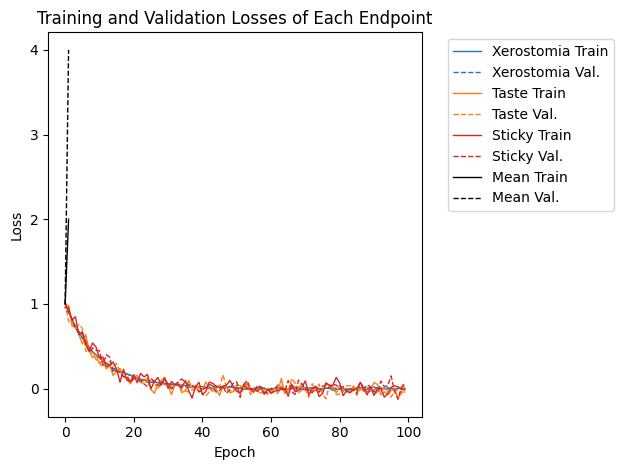

In [4]:
plot_losses_dict(0, train_losses_dict, val_losses_dict, [ 1,2], [1,4])

C:\Users\Daniel (7781D3A3)\AppData\Local\Temp\2\ipykernel_12692\2049781082.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


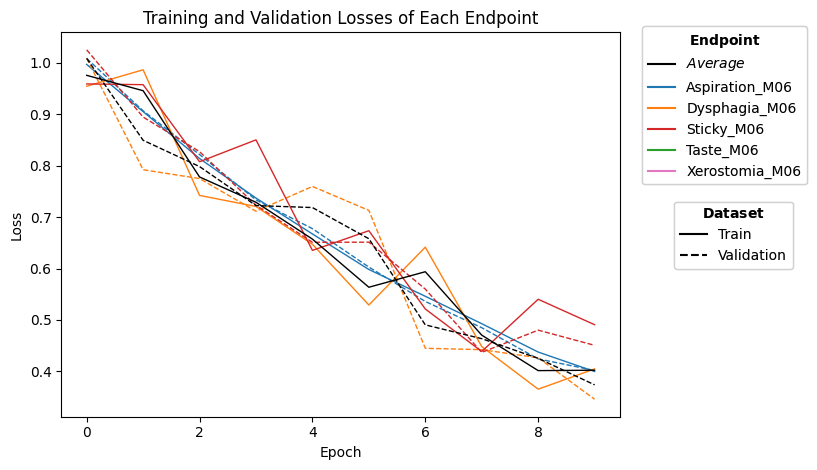

In [9]:
import os 
from copy import deepcopy
import config

names = deepcopy(config.endpoint_list)
colours = ['tab:blue', 'tab:orange', 'tab:red', 'tab:green', 'tab:pink', 'tab:purple', 'tab:brown', 'tab:cyan']
linestyles = ['solid', 'dashed', 'dotted', 'dashdot']
fig, axes = plt.subplots()

for idx, endpoint_name in enumerate(train_losses_dict.keys()):
    axes.plot(train_losses_dict[endpoint_name][:10], color = colours[idx], linestyle='solid', linewidth=1)
    axes.plot(val_losses_dict[endpoint_name][:10], color = colours[idx], linestyle='dashed', linewidth=1)

axes.plot(mean_train_loss_list[:10], label="Mean Train", color = "black", linestyle='solid', linewidth=1)
axes.plot(mean_val_loss_list[:10], label="Mean Val.", color = "black", linestyle='dashed', linewidth=1)

# add dummies in order to get the legend to look nice
colours.insert(0, 'black')
names.insert(0, '$\it{Average}$')
#linestyles.insert(0, 'solid')
dummy_color_lines = [axes.plot([], [], c=colours[idx], label=endpoint)[0] for idx, endpoint in enumerate(names)]
dummy_linestyles_lines = [axes.plot([], [], c='black', linestyle=linestyles[idx], label=set)[0] for idx, set in enumerate(["Train", "Validation"])]

legend = fig.legend(handles=dummy_color_lines, title='$\\bf{Endpoint}$', 
                     bbox_to_anchor=(1, 0.95), loc='upper left')
fig.add_artist(legend)

linestyle_legend = fig.legend(handles=dummy_linestyles_lines, title='$\\bf{Dataset}$', 
                              bbox_to_anchor=(1.05, 0.5), loc='center left')
fig.add_artist(linestyle_legend)


#linestyle_legend = plt.legend(handles=dummy_linestyles_lines, loc='upper right')

axes.set_xlabel('Epoch')
axes.set_ylabel('Loss')
axes.set_title("Training and Validation Losses of Each Endpoint")
fig.tight_layout()
save_path = 'all_toxicities losses.png'
fig.savefig(save_path,  bbox_inches='tight')
fig.show()

# fig.xlabel('Epoch')
# fig.ylabel('Loss')
# fig.title("Training and Validation Losses of Each Endpoint")
# fig.tight_layout()
# save_path = 'all_toxicities losses.png'
# fig.savefig(save_path,  bbox_inches='tight')
# fig.show()

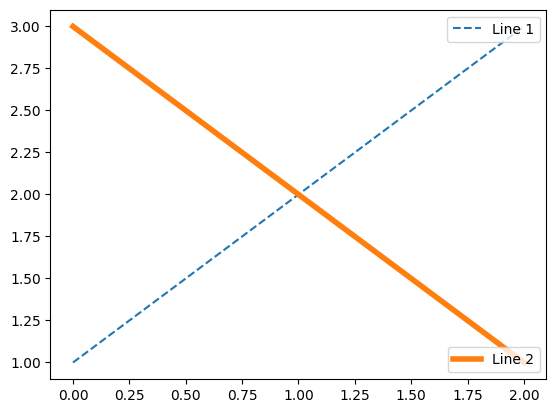

In [13]:
line1, = plt.plot([1, 2, 3], label="Line 1", linestyle='--')
line2, = plt.plot([3, 2, 1], label="Line 2", linewidth=4)

# Create a legend for the first line.
first_legend = plt.legend(handles=[line1], loc='upper right')

# Add the legend manually to the current Axes.
ax = plt.gca().add_artist(first_legend)

# Create another legend for the second line.
plt.legend(handles=[line2], loc='lower right')

plt.show()

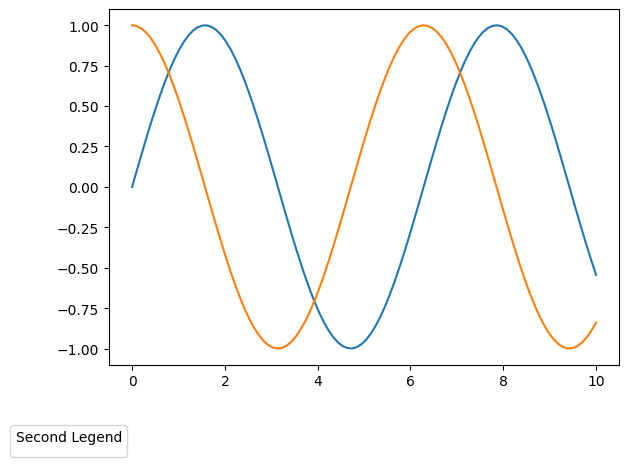

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)

fig, ax = plt.subplots()

# Plot data
ax.plot(x, y1, label='Sin')
ax.plot(x, y2, label='Cos')

# Add first legend
ax.legend(loc='upper right')

# Adjust for second legend
ax.legend([], [], loc='upper right', bbox_to_anchor=(0.05, -0.15), title='Second Legend')

# Add labels to the second legend manually
for i, text in enumerate(ax.get_legend().get_texts()):
    text.set_text('Label {}'.format(i+1))

plt.tight_layout()
plt.show()

In [ ]:
dummy_color_lines = [axes.plot([], [], c=color, label=f'Color {idx+1}')[0] for idx, color in enumerate(colors)]

# Creating dummy lines for linestyle legend
dummy_linestyle_lines = [axes.plot([], [], linestyle=ls, label=f'Line Style {idx+1}')[0] for idx, ls in enumerate(linestyles)]

# Adding color legend
color_legend = plt.legend(handles=dummy_color_lines, loc='upper left')
axes.add_artist(color_legend)

# Adding linestyle legend
linestyle_legend = plt.legend(handles=dummy_linestyle_lines + dummy_color_lines, loc='upper right')